Завантаження MNIST
Форма матриці X: (70000, 784)
Унікальні мітки y: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


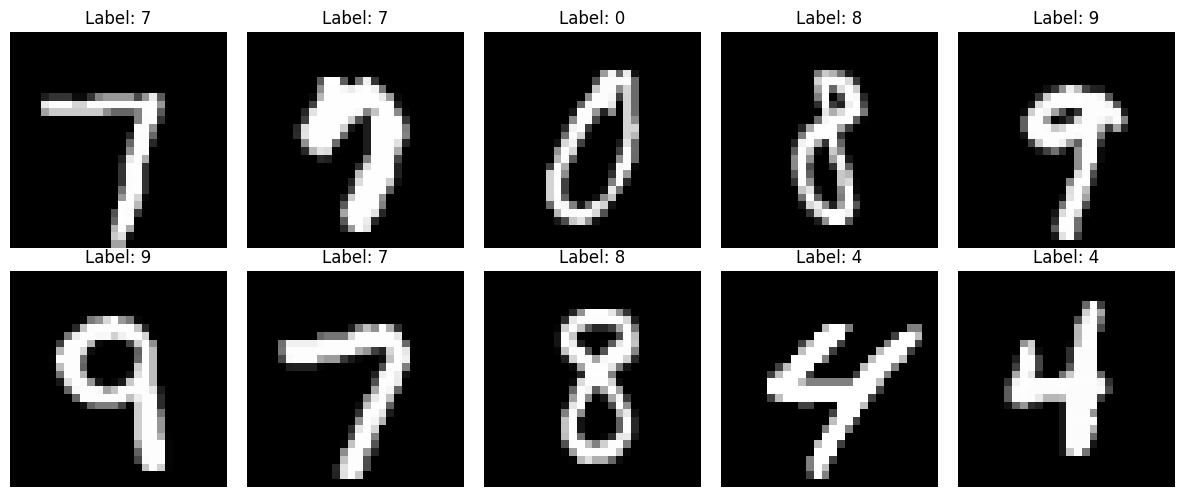

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

print("Завантаження MNIST")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


print(f"Форма матриці X: {X.shape}")
print(f"Унікальні мітки y: {np.unique(y)}")

plt.figure(figsize=(12, 5))
random_indices = np.random.choice(X.shape[0], 10, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [27]:
pca_3 = PCA(n_components=3)

X_pca = pca_3.fit_transform(X)
print(f"Форма X_pca: {X_pca.shape}")

explained_variance = pca_3.explained_variance_ratio_
for i, ev in enumerate(explained_variance):
    print(f"PC{i+1}: {ev:.4f} ({ev*100:.2f}%)")

total_var = np.sum(explained_variance)
print(f"Сумарна дисперсія: {total_var:.4f}")

Форма X_pca: (70000, 3)
PC1: 0.0975 (9.75%)
PC2: 0.0716 (7.16%)
PC3: 0.0615 (6.15%)
Сумарна дисперсія: 0.2305


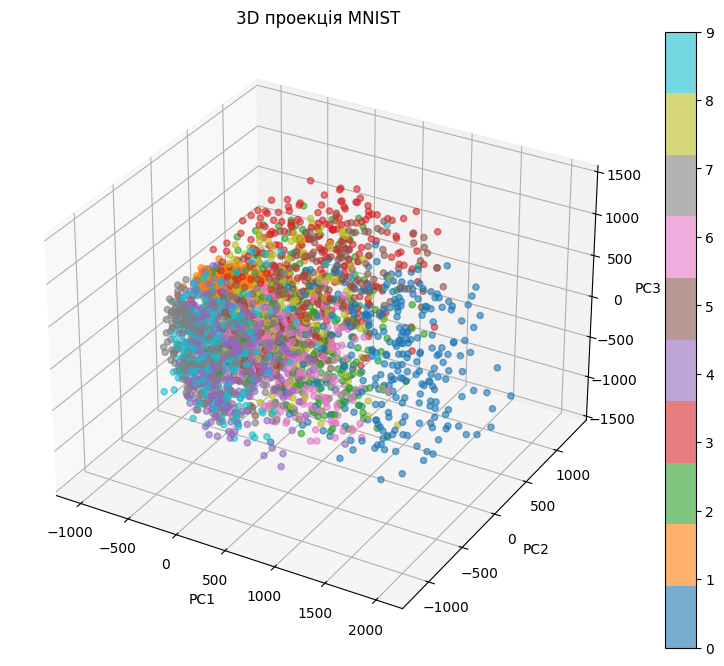

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

n_samples = 3000
scatter = ax.scatter(X_pca[:n_samples, 0], 
                     X_pca[:n_samples, 1], 
                     X_pca[:n_samples, 2], 
                     c=y[:n_samples].astype(int), 
                     cmap='tab10', alpha=0.6)

plt.colorbar(scatter)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D проекція MNIST')
plt.show()


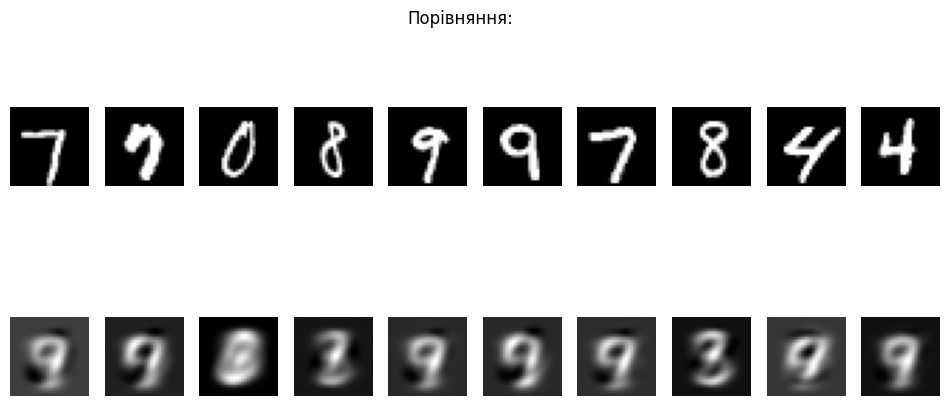

In [29]:
X_recovered = pca_3.inverse_transform(X_pca)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(X_recovered[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Reconstructed (3 PCs)")

plt.suptitle("Порівняння:")
plt.show()

k=2: MSE = 3635.53, Explained Variance = 0.1690
k=5: MSE = 2916.20, Explained Variance = 0.3334
k=10: MSE = 2234.86, Explained Variance = 0.4892
k=20: MSE = 1554.40, Explained Variance = 0.6447
k=50: MSE = 763.79, Explained Variance = 0.8254
k=100: MSE = 372.02, Explained Variance = 0.9150
k=200: MSE = 146.39, Explained Variance = 0.9665


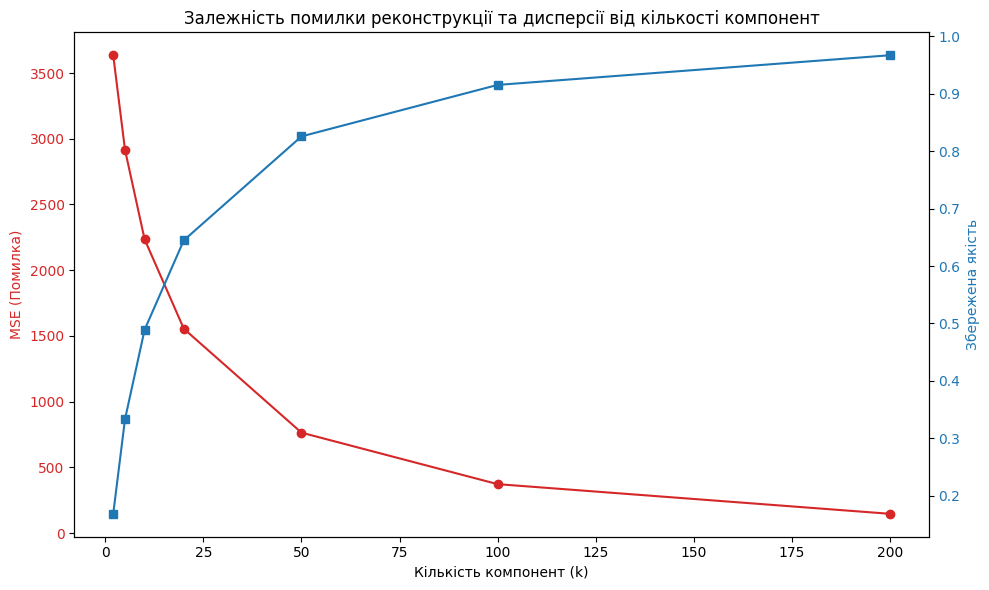

In [30]:
components_range = [2, 5, 10, 20, 50, 100, 200]
mse_list = []
variance_list = []


for k in components_range:
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X)
    X_rec_k = pca_k.inverse_transform(X_pca_k)
    
    mse = mean_squared_error(X, X_rec_k)
    var = np.sum(pca_k.explained_variance_ratio_)
    
    mse_list.append(mse)
    variance_list.append(var)
    print(f"k={k}: MSE = {mse:.2f}, Explained Variance = {var:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Кількість компонент (k)')
ax1.set_ylabel('MSE (Помилка)', color=color)
ax1.plot(components_range, mse_list, marker='o', color=color, label='MSE')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Збережена якість', color=color)
ax2.plot(components_range, variance_list, marker='s', color=color, label='Variance')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Залежність помилки реконструкції та дисперсії від кількості компонент')
fig.tight_layout()
plt.show()